In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon

In [3]:
import ipympl 
%matplotlib widget

In [4]:
import matplotlib
print(matplotlib.get_backend())

widget


# Data Prep

In [5]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file = base_folder / f"{whatFer}fer.h5ad"
# out_figs = base_folder / "figures"
# out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")

ST_sample = sc.read_h5ad(adata_file)

In [6]:
# COMPUTER
HNE_TIF_PATHS = {
    "F07839": Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/images_for_alignments/121724-121924_RL_mRT_TMA4_1_TMA5_1/hne/121724_RL_mRT_TMA4_Slide_1.tif"),
    "F07840": Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/images_for_alignments/121724-121924_RL_mRT_TMA4_1_TMA5_1/hne/121724_RL_mRT_TMA5_Slide_1.tif")
}



## Library selection

In [7]:
sample_name = "RTCyPSCA_1_4"
sample_name = 

lib_id = "F07839"
adata = ST_sample[ST_sample.obs['mouse']=="RTCyPSCA_1_4"].copy()

## Merging polygons

In [8]:
# Load nuclei polygons
segmentation_path = Path("/mnt/c/Users/jonan/Documents/1Work/Roselab/Spatial/CAR_T/data/cell_segmentation/")
gdf_file = segmentation_path / "concatenated" / "combined_nuclei_geometry.gpkg"
gdf = gpd.read_file(gdf_file)


# LIANA

In [9]:
li.ut.spatial_neighbors(adata, bandwidth=40, cutoff = 0.1, kernel='gaussian', set_diag=True)
lr = li.mt.bivariate(adata,
                resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=False
                )

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


In [ ]:
# gdf_file = segmentation_path /  "concatenated" / "combined_nuclei_geometry.gpkg"
# geo_file = gpd.read_file(gdf_file)

# gdf = geo.merge(ST_sample.obs[['id', 'n_counts']], on='id', how='inner')

# Finalizing

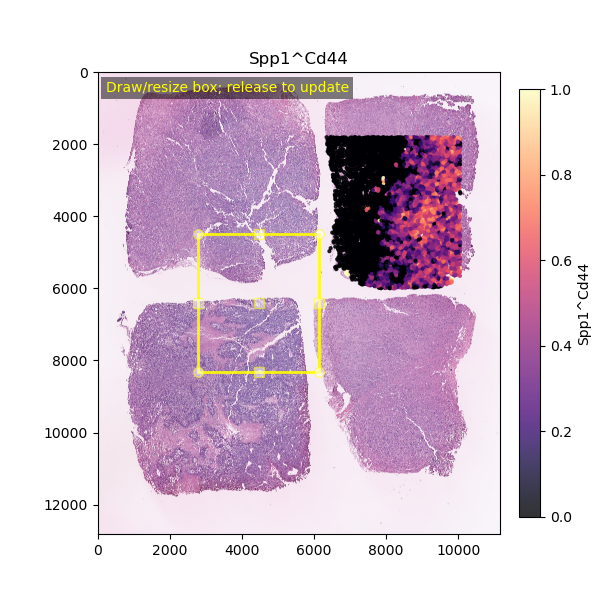

In [10]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import scipy.sparse as sp

pair = "Spp1^Cd44"
lib = "F07839"
img = ST_sample.uns["spatial"][lib]["images"]["hires"]   # full-res HxW[×3]
H, W = img.shape[:2]

# --- data (full-res pixel coords) ---
coords = np.asarray(lr.obsm["spatial"])                  # (n,2) in full-res pixels
vals   = lr[:, pair].X
vals   = vals.toarray().ravel() if sp.issparse(vals) else np.asarray(vals).ravel()

# --- plot image + points in the SAME coordinate system ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, origin="upper", extent=(0, W, H, 0))      # <- crucial: sets data coords = pixels
sc = ax.scatter(coords[:,0], coords[:,1], c=vals, s=4, cmap="magma", alpha=0.8)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=pair)
ax.set_xlim(0, W); ax.set_ylim(H, 0)                     # y downward like pixels
ax.set_title(pair)

# add once, after ax.set_title(...)
status = ax.text(
    0.02, 0.98, "Draw/resize box; release to update",
    transform=ax.transAxes, va="top", ha="left",
    color="yellow", bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)

# replace your onselect with this version
def onselect(eclick, erelease):
    if None in (eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata):
        status.set_text("Selection cancelled (drag fully inside axes)"); fig.canvas.draw_idle(); return
    x0, x1 = sorted([eclick.xdata,  erelease.xdata])
    y0, y1 = sorted([eclick.ydata,  erelease.ydata])
    sel = (coords[:,0] >= x0) & (coords[:,0] <= x1) & (coords[:,1] >= y0) & (coords[:,1] <= y1)
    state["sel"][:] = sel
    status.set_text(f"Picked: {sel.sum()} cells")
    fig.canvas.draw_idle()

# optional: press Enter to finalize (turn box green & freeze)
def on_key(event):
    if event.key in ("enter","return"):
        rect.set_active(False)
        try: rect.to_draw.set_edgecolor("lime")
        except: pass
        status.set_text(f"Final: {state['sel'].sum()} cells"); fig.canvas.draw_idle()

state = {"sel": np.zeros(coords.shape[0], dtype=bool)}

# make sure pan/zoom isn’t active (ipympl toolbar)
tb = getattr(fig.canvas, "toolbar", None)
if tb is not None:
    tb.mode = ""   # deactivate zoom/pan so events reach the selector

# keep a reference in a global / outer-scope var so it doesn't get GC'd
rect = RectangleSelector(
    ax, onselect,
    button=[1],                 # left mouse
    interactive=True,           # allow resize/move
    useblit=False,              # safer with %matplotlib widget
    drag_from_anywhere=True,    # easier to adjust
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2, alpha=0.9)
)

# optional: start with a small visible box
rect.extents = (W*0.25, W*0.55, H*0.35, H*0.65)

# finalize on Enter
cid_key = fig.canvas.mpl_connect("key_press_event", on_key)


In [11]:
# After you draw/adjust the yellow box and release the mouse:
mask = state["sel"].copy()
print("Selected:", mask.sum(), "/", len(mask))

selected_ids = lr.obs.index[mask]
print("First few IDs:", selected_ids[:10].tolist())

# optional: subset objects for downstream plots
lr_sel = lr[mask].copy()
adata_sel = ST_sample[ST_sample.obs.index.isin(selected_ids)].copy()


Selected: 3072 / 12667
First few IDs: ['ID_25781', 'ID_25787', 'ID_25791', 'ID_25798', 'ID_25809', 'ID_25815', 'ID_25831', 'ID_25837', 'ID_25845', 'ID_25847']


In [13]:
import numpy as np
import scipy.sparse as sp

def get_expr_matrix(adata, obs_index, genes, layer=None, case_insensitive=True):
    """
    It outputs a dense expression matrix (numpy.ndarray) with rows aligned 
    to obs_index and columns aligned to the subset of genes found in adata.var_names, 
    plus the list of those kept genes.
    """
    # optional case-insensitive matching
    if case_insensitive:
        vmap = {g.lower(): g for g in adata.var_names}
        genes_q = [g.lower() for g in genes]
        keep = [g for g in genes_q if g in vmap]
        missing = [genes[i] for i,g in enumerate(genes_q) if g not in vmap]
        var_names_kept = [vmap[g] for g in keep]
    else:
        keep = [g for g in genes if g in adata.var_names]
        missing = [g for g in genes if g not in adata.var_names]
        var_names_kept = keep

    if missing:
        print("Missing genes (skipped):", missing)
    if not var_names_kept:
        raise ValueError("None of the requested genes were found in adata.var_names.")

    # rows: obs_index in desired order
    row_idx = adata.obs.index.get_indexer(obs_index)
    if np.any(row_idx < 0):
        raise ValueError("Some obs in obs_index not found in adata.obs.index.")

    # cols: genes found
    col_idx = [adata.var_names.get_loc(g) for g in var_names_kept]

    M = adata.layers[layer] if layer is not None else adata.X
    # subset and densify
    if sp.issparse(M):
        Xsub = M.tocsr()[row_idx, :][:, col_idx].toarray()
    else:
        Xsub = np.asarray(M)[row_idx[:, None], col_idx]

    return Xsub, var_names_kept

In [56]:
import re
import numpy as np
import scipy.sparse as sp
import pandas as pd

# ---------- 1) Seed: core cytotoxic machinery (mouse symbols) ----------
core_cytotoxic = [
    # granule effector machinery
    "Prf1", "Nkg7", "Ifng", "Ctsw", "Cst7",
    # T/NK activation / cytotoxic-associated chemokines
    "Fasl", "Tnf", "Ccl5", "Xcl1",
    # CD8 T lineage / TCR complex
    "Cd8a", "Cd8b1", "Cd3d", "Cd3e", "Cd247",
    # NK lineage/core TFs (keep if present)
    "Ncr1", "Klrk1", "Eomes", "Tbx21"
]

# ---------- 2) Dynamically include *all* granzyme genes present ----------
# Any gene starting with "Gzm" (e.g., Gzma, Gzmb, Gzmk, Gzmm, ...)
var_lower_to_orig = {g.lower(): g for g in ST_sample.var_names}
granzyme_found = [var_lower_to_orig[v] for v in var_lower_to_orig.keys() if re.fullmatch(r"gzm[a-z0-9]+", v)]

# ---------- 3) Optionally include NK receptors if present (Ly49 / KLRC/D) ----------
nk_receptors_prefixes = ("Klra", "Klrb", "Klrc", "Klrd")  # Ly49/KLR families
nk_extra = [g for g in ST_sample.var_names if g.startswith(nk_receptors_prefixes)]

# ---------- 4) Build final candidate list & intersect with var_names ----------
candidates = list(dict.fromkeys(core_cytotoxic + granzyme_found + nk_extra))  # unique, keep order
present = [g for g in candidates if g in ST_sample.var_names]

if not present:
    raise ValueError("No cytotoxic genes from the panel were found in ST_sample.var_names.")

print(f"Cytotoxic panel found ({len(present)}):", present[:20], "..." if len(present) > 20 else "")

# ---------- 5) Pull expression aligned to lr.obs.index ----------
row_idx = ST_sample.obs.index.get_indexer(lr.obs.index)
col_idx = [ST_sample.var_names.get_loc(g) for g in present]

M = ST_sample.layers.get("counts", ST_sample.X)  # prefer raw counts layer if you have it
if sp.issparse(M):
    Xg = M.tocsr()[row_idx, :][:, col_idx].toarray()
else:
    Xg = np.asarray(M)[row_idx[:, None], col_idx]

# ---------- 6) Define cytotoxic gate ----------
thr = 0  # counts > 0 (adjust if you want stricter gate, e.g., >1)
any_pos_all = (Xg > thr).any(axis=1)        # OR gate across the panel
# Alternatives:
# all_pos_all = (Xg > thr).all(axis=1)      # AND gate (strict)
# at_least_k  = (Xg > thr).sum(axis=1) >= 2 # require >=2 cytotoxic genes

# ---------- 7) (Optional) make a cytotoxic *score* for plotting/thresholding ----------
# Use mean(log1p) over the panel, aligned to lr.obs
cyto_score = np.log1p(Xg).mean(axis=1)
# You can z-score if you want comparability:
# cyto_score = (cyto_score - cyto_score.mean()) / (cyto_score.std() + 1e-8)

# If you want to add the score to lr.obs for convenience:
lr.obs["cytotoxic_score"] = cyto_score


Cytotoxic panel found (44): ['Prf1', 'Nkg7', 'Ifng', 'Ctsw', 'Cst7', 'Fasl', 'Tnf', 'Ccl5', 'Xcl1', 'Cd8a', 'Cd8b1', 'Cd3d', 'Cd3e', 'Cd247', 'Ncr1', 'Klrk1', 'Eomes', 'Tbx21', 'Gzmm', 'Gzma'] ...


In [57]:
# --- summary for the current selection using the broad cytotoxic panel ---
thr = 0  # same threshold used above
any_pos_sel = any_pos_all[mask]
print(f"In selection: {any_pos_sel.sum()} / {mask.sum()} cells express any cytotoxic gene")

# Per-gene counts within selection (using the panel you built as `present`)
per_gene_counts = (Xg[mask] > thr).sum(axis=0)
print("Per-gene in selection:", dict(zip(present, per_gene_counts.tolist())))

In selection: 981 / 3072 cells express any cytotoxic gene
Per-gene in selection: {'Prf1': 39, 'Nkg7': 33, 'Ifng': 12, 'Ctsw': 4, 'Cst7': 6, 'Fasl': 5, 'Tnf': 23, 'Ccl5': 340, 'Xcl1': 2, 'Cd8a': 4, 'Cd8b1': 4, 'Cd3d': 3, 'Cd3e': 0, 'Cd247': 0, 'Ncr1': 14, 'Klrk1': 70, 'Eomes': 2, 'Tbx21': 1, 'Gzmm': 4, 'Gzma': 58, 'Gzmk': 0, 'Gzme': 84, 'Gzmd': 154, 'Gzmg': 52, 'Gzmn': 0, 'Gzmf': 99, 'Gzmc': 227, 'Gzmb': 153, 'Klrb1a': 3, 'Klrb1': 1, 'Klrb1c': 0, 'Klrb1b': 31, 'Klrb1f': 0, 'Klrd1': 3, 'Klrc3': 0, 'Klrc1': 5, 'Klra17': 0, 'Klra5': 0, 'Klra6': 1, 'Klra4': 4, 'Klra8': 1, 'Klra7': 3, 'Klra3': 0, 'Klra2': 40}


In [14]:
# # ---------- configure your gene set ----------
# # genes = ["Cd8a", "Cd8b1"]# "Gzmb", "Prf1"]        # example set
# genes = ["Gzmb", "Prf1"]
# thr   = 0                               # expression threshold (counts > thr)
# layer = None                            # or "counts" if you stored counts in a layer

# # expression for ALL cells in lr (aligned to lr.obs.index)
# Xg, genes_found = get_expr_matrix(ST_sample, lr.obs.index, genes, layer=layer)

# # any-positive across the gene set for each cell
# any_pos_all = (Xg > thr).any(axis=1)

# # restrict to your previously selected cells
# any_pos_sel = any_pos_all[mask]         # mask is your rectangle selection (length = lr.n_obs)

# print(f"In selection: {any_pos_sel.sum()} / {mask.sum()} cells express any of {genes_found}")
# # (Optional) per-gene counts within the selection:
# per_gene_counts = (Xg[mask] > thr).sum(axis=0)
# print("Per-gene in selection:", dict(zip(genes_found, per_gene_counts)))

In selection: 183 / 3072 cells express any of ['Gzmb', 'Prf1']
Per-gene in selection: {'Gzmb': 153, 'Prf1': 39}


In [58]:
# --- thresholds & categories ---
pct = 0.45
thr_int = np.quantile(vals[mask], pct) if mask.any() else np.quantile(vals, pct)

sel       = mask #TODO: repalce this redundancy
int_high  = vals >= thr_int
gene_pos  = any_pos_all #TODO: repalce this redundancy

INT_HIGH  = sel & int_high                  # includes BOTH by definition (priority to interaction)
GENE_ONLY = sel & (~int_high) & gene_pos    # NOt high in the interaction
OTHER     = sel & (~int_high) & (~gene_pos) # Everything else

# --- crop to selected region (+ padding) ---
coords_all = np.asarray(lr.obsm["spatial"]) 
coords_sel = coords_all[sel]
pad = 100
xmin = max(0, int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W, int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0, int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H, int(np.ceil (coords_sel[:,1].max()) + pad))

img_crop = img[ymin:ymax, xmin:xmax]
h, w = img_crop.shape[:2]

def adj(mask_):
    c = coords_all[mask_].copy()
    c[:,0] -= xmin; c[:,1] -= ymin
    return c

C_INT  = adj(INT_HIGH)
C_GENE = adj(GENE_ONLY)
C_OTH  = adj(OTHER)

In [59]:
from shapely.affinity import translate

# Ensure there is an 'id' column matching lr.obs['id']
if "id" not in gdf.columns:
    gdf = gdf.reset_index().rename(columns={"index": "id"})

# Keep only polygons from the currently selected IDs
sel_ids = lr.obs.index[sel]  # 'sel' is your boolean mask for the rectangle selection
gdf_sel = gdf[gdf["id"].isin(sel_ids)].copy()

# Build category labels per-cell (priority to interaction)
# (Cells that are both int_high & gene_pos are considered INT_HIGH)
cat = np.full(lr.shape[0], "OTHER", dtype=object)
cat[GENE_ONLY] = "GENE_ONLY"
cat[INT_HIGH]  = "INT_HIGH"

cat_map = pd.Series(cat, index=lr.obs.index)  # id -> category
gdf_sel["category"] = gdf_sel["id"].map(cat_map)

# Drop anything that somehow didn't get a category (shouldn't happen, but safe)
gdf_sel = gdf_sel[gdf_sel["category"].notna()].copy()

# Shift polygons into the crop frame (subtract xmin, ymin), same as 'adj' for points
gdf_sel["geometry"] = gdf_sel["geometry"].apply(lambda geom: translate(geom, xoff=-xmin, yoff=-ymin))

# (Optional) quick counts
poly_counts = gdf_sel["category"].value_counts()
print("Polygon counts in crop:", dict(poly_counts))

Polygon counts in crop: {'INT_HIGH': 1690, 'OTHER': 865, 'GENE_ONLY': 517}


In [60]:
# Adding spp1 color scale

# --- attach continuous interaction values to polygons ---
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# map lr.obs.index -> interaction value
val_map = pd.Series(vals, index=lr.obs.index)  # 'vals' is your interaction vector
gdf_sel["int_val"] = gdf_sel["id"].map(val_map)

# establish color scale on INT_HIGH cells within the selection
v = gdf_sel.loc[gdf_sel["category"] == "INT_HIGH", "int_val"].to_numpy()
if v.size == 0:
    vmin, vmax = 0.0, 1.0  # fallback
else:
    vmin, vmax = float(np.nanmin(v)), float(np.nanmax(v))
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("magma")

/tmp/ipykernel_16688/1016471278.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


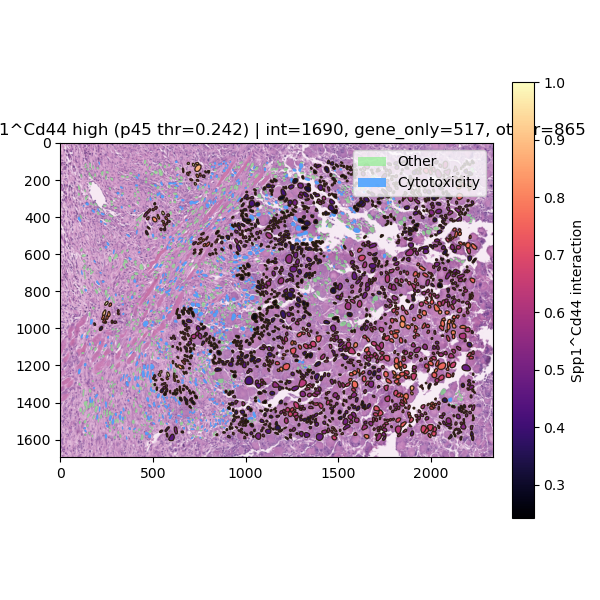

In [62]:
# --- PLOT POLYGONS (INT_HIGH colored by magma; others as outlines) ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_crop, origin="upper", extent=(0, w, h, 0))

# 1) OTHER (grey outline)
sub = gdf_sel[gdf_sel["category"] == "OTHER"]
if not sub.empty:
    sub.plot(ax=ax, facecolor="lightgreen", linewidth=0.4, alpha=0.7, zorder=1, label="Other")

# 2) GENE_ONLY (blue outline)
sub = gdf_sel[gdf_sel["category"] == "GENE_ONLY"]
if not sub.empty:
    sub.plot(ax=ax, facecolor="#4ea3ff", linewidth=0.8, alpha=0.9, zorder=2, label="Gene+ only")

# 3) INT_HIGH (filled by continuous 'int_val' with magma)
sub = gdf_sel[gdf_sel["category"] == "INT_HIGH"]
if not sub.empty:
    # geodataframe.plot with 'column' uses the colormap; we'll add a colorbar manually
    coll = sub.plot(
        ax=ax, column="int_val", cmap="magma", linewidth=0.9, edgecolor="#2b1d0e",
        alpha=0.95, zorder=3, legend=False  # legend=False; we'll attach a ScalarMappable colorbar
    )
    # make a colorbar for the magma-mapped interaction values
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f"{pair} interaction")

ax.set_xlim(0, w); ax.set_ylim(h, 0)
ax.set_title(
    f"{pair} high (p{int(pct*100)} thr={thr_int:.3g}) | "
    f"int={INT_HIGH.sum()}, gene_only={GENE_ONLY.sum()}, other={OTHER.sum()}"
)

from matplotlib.patches import Patch

handles = [
    Patch(facecolor="lightgreen", edgecolor="none", alpha=0.7, label="Other"),
    Patch(facecolor="#4ea3ff", alpha=0.9, label="Cytotoxicity"),
    # INT_HIGH is represented by the magma colorbar, so we don't add a legend patch for it
]

ax.legend(handles=handles, loc="upper right", frameon=True)

plt.tight_layout()


# Final Figure

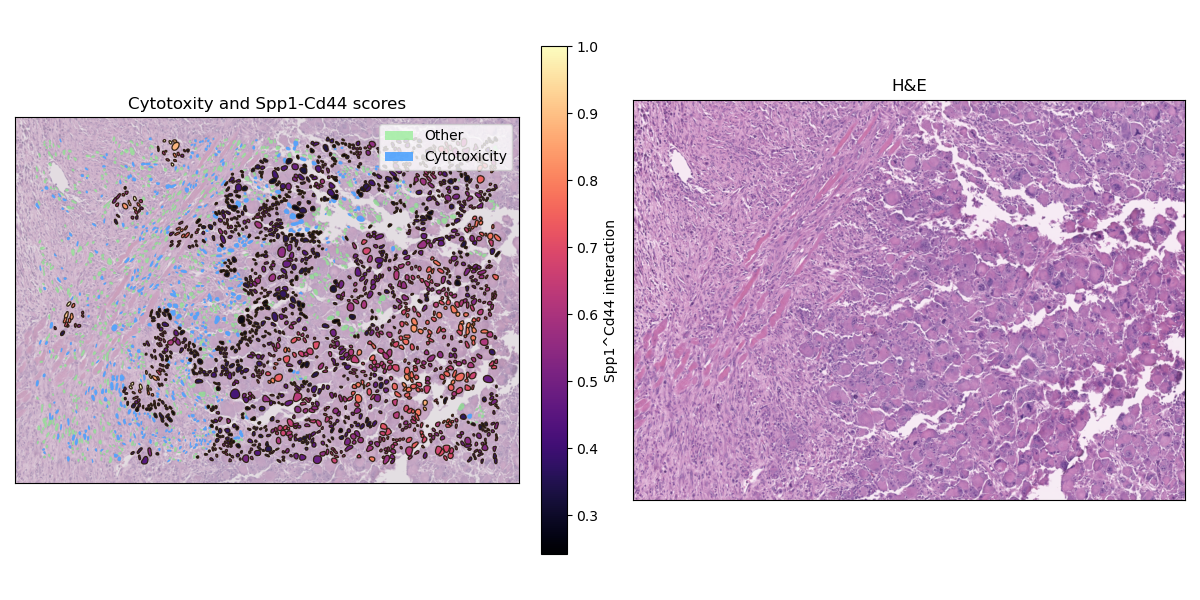

In [71]:
# --- SIDE-BY-SIDE: polygons (left) + H&E only (right) ---
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

fig, (axL, axR) = plt.subplots(ncols=2, figsize=(12,6))

# # common background image (both panes), same extent so pixels == data coords
# for ax_ in (axL, axR):
#     ax_.imshow(img_crop, origin="upper", extent=(0, w, h, 0))
#     ax_.set_xlim(0, w); ax_.set_ylim(h, 0)

# --- LEFT: H&E with custom opacity/brightness (and optional gamma) ---
he_alpha_left      = 0.6   # 0 = fully transparent, 1 = fully opaque
he_brightness_left = 0.85  # <1 darker, >1 brighter (linear gain)
he_gamma_left      = 1.0   # <1 brighten midtones, >1 darken midtones

imgL = img_crop.astype(np.float32) / 255.0
imgL = np.clip(imgL * he_brightness_left, 0.0, 1.0)
if he_gamma_left != 1.0:
    imgL = np.clip(imgL ** he_gamma_left, 0.0, 1.0)

axL.imshow(imgL, origin="upper", extent=(0, w, h, 0), alpha=he_alpha_left)
axL.set_xlim(0, w); axL.set_ylim(h, 0)

# --- RIGHT: H&E as-is (no changes) ---
axR.imshow(img_crop, origin="upper", extent=(0, w, h, 0))
axR.set_xlim(0, w); axR.set_ylim(h, 0)

# ---------- LEFT: polygons ----------
# 1) OTHER
sub = gdf_sel[gdf_sel["category"] == "OTHER"]
if not sub.empty:
    sub.plot(ax=axL, facecolor="lightgreen", edgecolor="none",
             linewidth=0.4, alpha=0.7, zorder=1)

# 2) GENE_ONLY
sub = gdf_sel[gdf_sel["category"] == "GENE_ONLY"]
if not sub.empty:
    sub.plot(ax=axL, facecolor="#4ea3ff", edgecolor="none",
             linewidth=0.8, alpha=0.9, zorder=2)

# 3) INT_HIGH (continuous magma fill using 'int_val')
sub = gdf_sel[gdf_sel["category"] == "INT_HIGH"]
if not sub.empty:
    # use the same norm/cmap you computed earlier
    sub.plot(ax=axL, column="int_val", cmap="magma",
             linewidth=0.9, edgecolor="#2b1d0e", alpha=0.95, zorder=3, legend=False)
    # colorbar attached to LEFT axis only
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)  # 'norm', 'cmap' from earlier insert
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=axL, fraction=0.046, pad=0.04)
    cbar.set_label(f"{pair} interaction")

axL.set_title("Cytotoxity and Spp1-Cd44 scores"
    # f"{pair} high (p{int(pct*100)} thr={thr_int:.3g}) | "
    # f"int={INT_HIGH.sum()}, gene_only={GENE_ONLY.sum()}, other={OTHER.sum()}"
)

# Categorical legend (INT_HIGH is represented by the colorbar)
handles = [
    Patch(facecolor="lightgreen", edgecolor="none", alpha=0.7, label="Other"),
    Patch(facecolor="#4ea3ff", edgecolor="none", alpha=0.9, label="Cytotoxicity"),
]
axL.legend(handles=handles, loc="upper right", frameon=True)

# ---------- RIGHT: H&E only ----------
axR.set_title("H&E")
# optional: remove ticks/frames for cleaner look
for ax_ in (axL, axR):
    ax_.set_xticks([]); ax_.set_yticks([])

plt.tight_layout()

from pathlib import Path

In [ ]:
# --- save outputs ---
out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")
out_figs.mkdir(parents=True, exist_ok=True)

stem = f"{lib}_{pair}_polys_vs_he_crop"   # tweak if you want a different filename
png_path = out_figs / f"{stem}.png"
pdf_path = out_figs / f"{stem}.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
fig.savefig(pdf_path,              bbox_inches="tight", pad_inches=0.02)

print("Saved:", png_path)
print("Saved:", pdf_path)